[Kaggle Multilingual app data](https://www.kaggle.com/datasets/pratyushpuri/multilingual-mobile-app-reviews-dataset-2025)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Data/multilingual_mobile_app_reviews_2025.csv')
df.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
0,1,1967825,MX Player,Travel & Local,Qui doloribus consequuntur. Perspiciatis tempo...,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14.0,China,Female,1.4
1,2,9242600,Tinder,Navigation,"Great app but too many ads, consider premium v...",ru,1.6,2024-06-21 17:29:40,True,iPad,209,18.0,Germany,Male,8.9
2,3,7636477,Netflix,Dating,The interface could be better but overall good...,es,3.6,2024-10-31 13:47:12,True,iPad,163,67.0,Nigeria,Male,2.8.37.5926
3,4,209031,Venmo,Productivity,"Latest update broke some features, please fix ...",vi,3.8,2025-03-12 06:16:22,True,iOS,664,66.0,India,Female,10.2
4,5,7190293,Google Drive,Education,"Perfect for daily use, highly recommend to eve...",tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40.0,South Korea,Prefer not to say,4.7


### Data exploration

In [25]:
print(df.shape)
print()
print(df.size)
print()
print(df.dtypes)

(2514, 14)

35196

review_id                     int64
user_id                       int64
app_name                     object
app_category                 object
review_language              object
rating                      float64
review_date          datetime64[ns]
verified_purchase              bool
device_type                  object
num_helpful_votes             int64
user_age                      int64
user_country                 object
user_gender                  object
app_version                  object
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          2514 non-null   int64  
 1   user_id            2514 non-null   int64  
 2   app_name           2514 non-null   object 
 3   app_category       2514 non-null   object 
 4   review_text        2455 non-null   object 
 5   review_language    2514 non-null   object 
 6   rating             2477 non-null   float64
 7   review_date        2514 non-null   object 
 8   verified_purchase  2514 non-null   bool   
 9   device_type        2514 non-null   object 
 10  num_helpful_votes  2514 non-null   int64  
 11  user_age           2514 non-null   float64
 12  user_country       2473 non-null   object 
 13  user_gender        1927 non-null   object 
 14  app_version        2484 non-null   object 
dtypes: bool(1), float64(2), int64(3), object(9)
memory usage: 277.6+ KB


In [5]:
df.isnull().sum()

review_id              0
user_id                0
app_name               0
app_category           0
review_text           59
review_language        0
rating                37
review_date            0
verified_purchase      0
device_type            0
num_helpful_votes      0
user_age               0
user_country          41
user_gender          587
app_version           30
dtype: int64

In [6]:
# the review text column is not important for analysis purpose so the column is dropped
df.drop(columns='review_text',inplace=True)
df.head()

,review_id,user_id,app_name,app_category,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
0,1,1967825,MX Player,Travel & Local,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14.0,China,Female,1.4
1,2,9242600,Tinder,Navigation,ru,1.6,2024-06-21 17:29:40,True,iPad,209,18.0,Germany,Male,8.9
2,3,7636477,Netflix,Dating,es,3.6,2024-10-31 13:47:12,True,iPad,163,67.0,Nigeria,Male,2.8.37.5926
3,4,209031,Venmo,Productivity,vi,3.8,2025-03-12 06:16:22,True,iOS,664,66.0,India,Female,10.2
4,5,7190293,Google Drive,Education,tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40.0,South Korea,Prefer not to say,4.7


In [7]:
df['review_date'] = pd.to_datetime(df['review_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          2514 non-null   int64         
 1   user_id            2514 non-null   int64         
 2   app_name           2514 non-null   object        
 3   app_category       2514 non-null   object        
 4   review_language    2514 non-null   object        
 5   rating             2477 non-null   float64       
 6   review_date        2514 non-null   datetime64[ns]
 7   verified_purchase  2514 non-null   bool          
 8   device_type        2514 non-null   object        
 9   num_helpful_votes  2514 non-null   int64         
 10  user_age           2514 non-null   float64       
 11  user_country       2473 non-null   object        
 12  user_gender        1927 non-null   object        
 13  app_version        2484 non-null   object        
dtypes: bool(

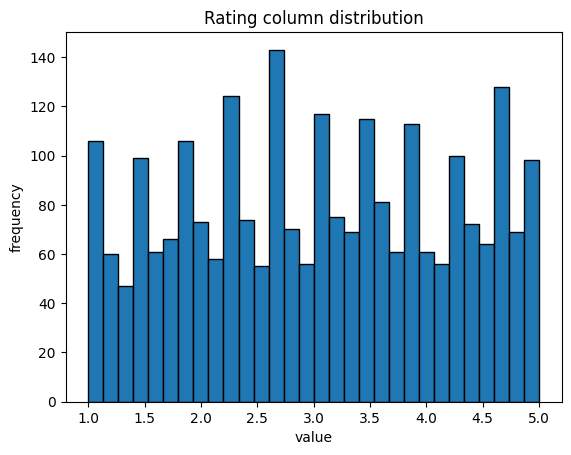

In [12]:
# analysing the skewness of rating column data
plt.hist (df['rating'].dropna(), bins=30, edgecolor='black')
plt.title('Rating column distribution')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [16]:
median_rat = df['rating'].median()

df['user_age'] = df['user_age'].astype(np.int64)
df['rating'] = df['rating'].fillna(median_rat)
df['user_country'] = df['user_country'].fillna('Not specified')
df['user_gender'] = df['user_gender'].fillna('Prefer not to say')
df['app_version'] = df['app_version'].fillna('Unknown')
df.head()


,review_id,user_id,app_name,app_category,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
0,1,1967825,MX Player,Travel & Local,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14,China,Female,1.4
1,2,9242600,Tinder,Navigation,ru,1.6,2024-06-21 17:29:40,True,iPad,209,18,Germany,Male,8.9
2,3,7636477,Netflix,Dating,es,3.6,2024-10-31 13:47:12,True,iPad,163,67,Nigeria,Male,2.8.37.5926
3,4,209031,Venmo,Productivity,vi,3.8,2025-03-12 06:16:22,True,iOS,664,66,India,Female,10.2
4,5,7190293,Google Drive,Education,tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40,South Korea,Prefer not to say,4.7


In [18]:
#optional data checks for uniformity
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]
df = df[(df['user_age'] >= 13) & (df['user_age'] <= 100)]

In [19]:
df.isnull().sum()

review_id            0
user_id              0
app_name             0
app_category         0
review_language      0
rating               0
review_date          0
verified_purchase    0
device_type          0
num_helpful_votes    0
user_age             0
user_country         0
user_gender          0
app_version          0
dtype: int64

### EDA

In [23]:
df['rating']

0       1.3
1       1.6
2       3.6
3       3.8
4       3.2
       ... 
2509    3.0
2510    1.9
2511    3.4
2512    2.7
2513    2.1
Name: rating, Length: 2514, dtype: float64

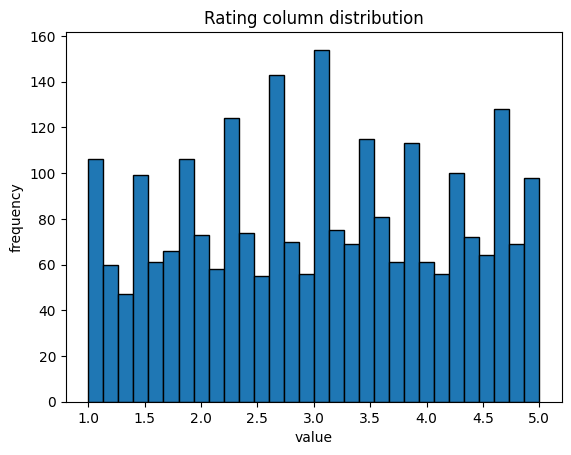

In [21]:
# rating distibution
plt.hist (df['rating'].sort_values(), bins=30, edgecolor='black')
plt.title('Rating column distribution')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [26]:
df.columns

Index(['review_id', 'user_id', 'app_name', 'app_category', 'review_language',
       'rating', 'review_date', 'verified_purchase', 'device_type',
       'num_helpful_votes', 'user_age', 'user_country', 'user_gender',
       'app_version'],
      dtype='object')

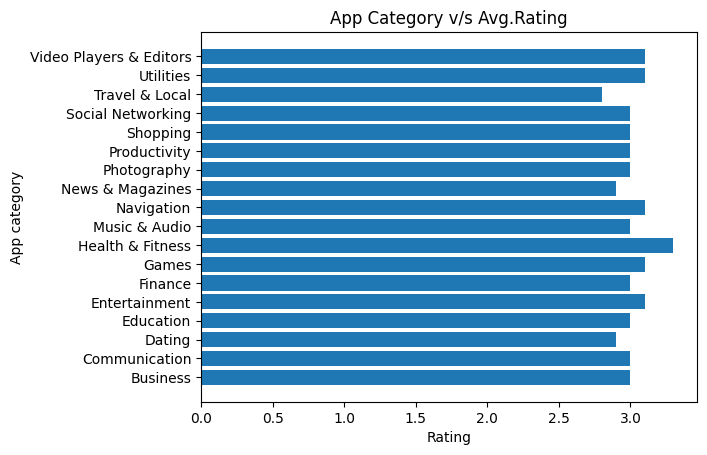

In [36]:
# App category vs. average rating
app_cat = df.groupby(['app_category'])['rating'].mean().reset_index().round(1)



plt.barh(app_cat['app_category'], app_cat['rating'])
plt.title('App Category v/s Avg.Rating')
plt.ylabel('App category')
plt.xlabel('Rating')
plt.show()



In [49]:
print(f'Min rating in data {df['rating'].min()}, Max rating in data {df['rating'].max()}')

df.loc[df['rating'] == 5.0, ['app_name', 'app_category', 'rating', 'user_country']]

Min rating in data 1.0, Max rating in data 5.0


,app_name,app_category,rating,user_country
5,Netflix,Music & Audio,5.0,Spain
45,OneDrive,Navigation,5.0,Brazil
134,Google Drive,Navigation,5.0,Turkey
143,Zoom,Finance,5.0,Indonesia
146,Spotify,Utilities,5.0,Russia
268,Bumble,Photography,5.0,Indonesia
283,Lyft,Entertainment,5.0,Thailand
342,Zoom,Business,5.0,Philippines
488,Bumble,Navigation,5.0,France
584,Reddit,Entertainment,5.0,Malaysia
